<div align="center">

# Assignment 3 - Transformers and Attention

</div>

**Course:** Advanced Data Mining  
**Deadline:** 23.03.2026 7:00 (SKOS), 16-24.03.2026 (presentation)

---

## General remark

Your solution should take the form of a short report (e.g. in Overleaf, HackMD, etc.).

The implementation code for **Task 3** should be provided as a `.py` file or a **Jupyter Notebook**.

---

# Task 1: Properties of the Attention Matrix [1 point]

Consider the self-attention mechanism defined as

$$
A = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)
$$

where the softmax function is applied **row-wise**.  
The matrices $Q, K \in \mathbb{R}^{n \times d_k}$ represent **queries** and **keys** respectively.

### Questions

1. Show that every element of the attention matrix $A$ is **strictly positive**.

2. Prove that the **sum of elements in each row of $A$** is equal to **1**.

3. Provide a **probabilistic interpretation** of the element $A_{ij}$ in the context of the attention mechanism.

### Hint

Recall that for a vector $z \in \mathbb{R}^n$ the softmax function is defined as

$$
\text{softmax}(z)_i =
\frac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}
$$

---



# Task 2: Linear Structure of Sinusoidal Positional Encoding [2 points]

In the original Transformer architecture, sinusoidal positional encodings are defined as

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d}}\right)
$$

$$
PE(pos, 2i + 1) = \cos\left(\frac{pos}{10000^{2i/d}}\right)
$$

where:

- $pos$ denotes the **position in the sequence**
- $i$ indexes the **embedding dimension**

### Questions

1. Consider two positions $p$ and $q$ in the sequence. Write explicitly the positional encoding vectors $PE(p)$ and $PE(q)$ for a single pair of coordinates $(2i, 2i+1)$.

2. Show that the positional encoding at position $p$ can be expressed as a **linear transformation** of the positional encoding at position $q$ that depends only on the offset

$$
\Delta = p - q
$$

3. Conclude that there exists a matrix $M_{\Delta}$ such that

$$
PE(p) = M_{\Delta} PE(q)
$$

Finally, discuss **why this property may be useful for modeling relative token positions in Transformer architectures**.

---

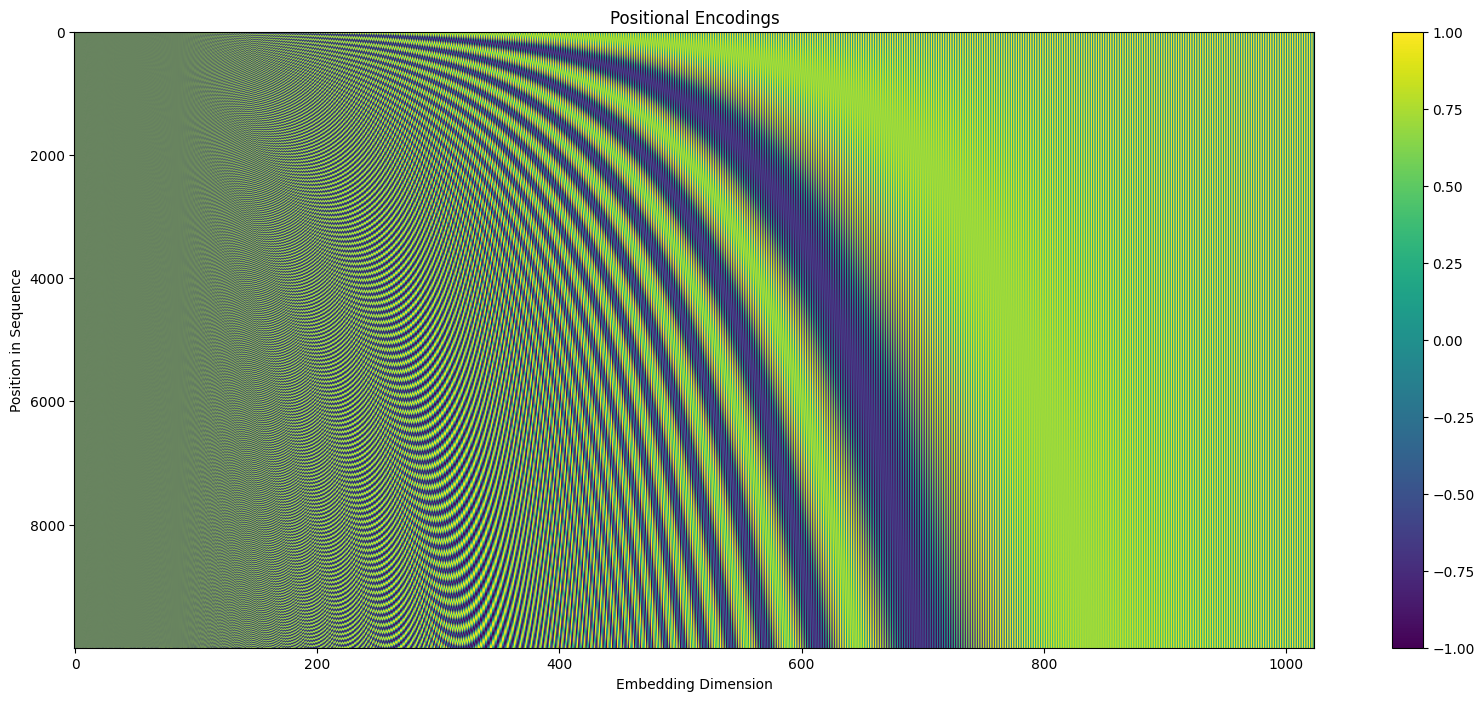

In [4]:
import numpy as np

import matplotlib.pyplot as plt

def get_positional_encodings(seq_len, d, n=10**5):
    positional_encodings = np.zeros(shape=(seq_len, d))

    for pos in range(seq_len):
        for i in range(d // 2):
            angle_arg = pos / np.power(n, 2 * i / d)
            positional_encodings[pos, 2 * i] = np.sin(angle_arg)
            positional_encodings[pos, 2 * i + 1] = np.cos(angle_arg)

    return positional_encodings

sequence_len = 10000 # Number of tokens
d_model = 1024 # Embedding dimensions

positional_encodings = get_positional_encodings(sequence_len, d_model)

plt.figure(figsize=(20, 8))
plt.imshow(positional_encodings, cmap='viridis', aspect='auto')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position in Sequence')
plt.title('Positional Encodings')
plt.colorbar()
plt.show()



# Task 3: Implementing a Transformer [2 points]

Using the tutorials below, implement and train a **Transformer model**.

### Tutorials

- Building a Transformer from Scratch - Part 1
- Building a Transformer from Scratch - Part 2

During the **lab session** you will be asked two questions about your implementation.

### Grading

- **1 point** - correct implementation and successful execution of the code
- **1 point** - correct answer to the questions


Building Transformer from scratch

In [ ]:
import torch
import torch.nn as nn
import math

class InputEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.d_model = d_model                              # The dimension of the embedding space
        self.vocab_size = vocab_size                        # The size of the vocabulary
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.embedding.embedding_dim)
    
    # Why the varaince of the embedding is scaled by the square root of the embedding dimension?
    # The variance of the embedding is scaled by the square root of the embedding dimension to ensure
    # that the magnitude of the embeddings remains consistent regardless of the embedding dimension.
    # This scaling helps to prevent the embeddings from becoming too large or too small as the embedding
    # dimension changes, which can improve the stability and performance of the model during training.


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, seq: int, dropout: float):
        super().__init__()
        self.d_model = d_model
        self.seq = seq
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(seq, d_model)
        position = torch.arange(0, seq).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.shape[1], :]
        return self.dropout(x)
    

class LayerNormalization(nn.Module):
    def __init__(self, features: int, eps: float = 1e-6) -> None:
        super().__init__()
        self.features = features
        self.eps = eps
        self.alpha = nn.Parameter(torch.ones(features))
        self.bias = nn.Parameter(torch.zeros(features))

    def forward(self, x):
        mean  = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True)
        return self.alpha * (x - mean) / (std + self.eps) + self.bias
    
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float) -> None:
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        x = self.linear1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        return self.linear2(x)
        # return self.linear_2(self.dropout(torch.relu(self.linear_1(x))))


class MultiHeadAttentionBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float) -> None:
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.dropout = nn.Dropout(dropout)

        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_k = d_model // num_heads

        self.linear_q = nn.Linear(d_model, d_model, bias=False)
        self.linear_k = nn.Linear(d_model, d_model, bias=False)
        self.linear_v = nn.Linear(d_model, d_model, bias=False)
        self.linear_out = nn.Linear(d_model, d_model, bias=False)

    @staticmethod
    def attention(query, key, value, mask, dropout: nn.Module):
        d_k = query.shape[-1]
        attention_scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            attention_scores = attention_scores.masked_fill(mask == 0, -1e9)

        if dropout is not None:
            attention_scores = dropout(attention_scores)

        return torch.matmul(attention_scores, value), attention_scores

    def forward(self, query, key, value, mask=None):
        query = self.linear_q(query)
        key = self.linear_k(key)
        value = self.linear_v(value)

        query = query.view(query.shape[0], query.shape[1], self.num_heads, self.d_k).transpose(1, 2)
        key = key.view(key.shape[0], key.shape[1], self.num_heads, self.d_k).transpose(1, 2)
        value = value.view(value.shape[0], value.shape[1], self.num_heads, self.d_k).transpose(1, 2)

        x, self.attention_scores = MultiHeadAttentionBlock.attention(query, key, value, mask, self.dropout)

        x = x.transpose(1, 2).contiguous().view(x.shape[0], -1, self.d_model)

        return self.linear_out(x)
    
class ResidualConnection(nn.Module):
    def __init__(self, features: int, dropout: float) -> None:
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = LayerNormalization(features)

    def forward(self, x, sublayer):
        return x + self.dropout(sublayer(self.layer_norm(x)))
        
class EncoderBlock(nn.Module):
    def __init__(self, features: int, self_attention_block: MultiHeadAttentionBlock, feed_forward_block: FeedForwardBlock, dropout: float) -> None:
        super().__init__()
        self.self_attention_block = self_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connection1 = ResidualConnection(features, dropout)
        self.residual_connection2 = ResidualConnection(features, dropout)

    def forward(self, x, mask=None):
        x = self.residual_connection1(x, lambda x: self.self_attention(x, x, x, mask))
        return self.residual_connection2(x, self.feed_forward)

class Encoder(nn.Module):
    def __init__(self, features: int, layers: nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers
        self.layer_norm = LayerNormalization(features)

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return self.layer_norm(x)
    

class DecoderBlock(nn.Module):

    def __init__(self, features: int, self_attention_block: MultiHeadAttentionBlock, cross_attention_block: MultiHeadAttentionBlock, feed_forward_block: FeedForwardBlock, dropout: float) -> None:
        super().__init__()
        self.self_attention_block = self_attention_block
        self.cross_attention_block = cross_attention_block
        self.feed_forward_block = feed_forward_block
        self.residual_connection1 = ResidualConnection(features, dropout)
        self.residual_connection2 = ResidualConnection(features, dropout)
        self.residual_connection3 = ResidualConnection(features, dropout)

        def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
            x = self.residual_connection1(x, lambda x: self.self_attention_block(x, x, x, tgt_mask))
            x = self.residual_connection2(x, lambda x: self.cross_attention_block(x, encoder_output, encoder_output, src_mask))
            return self.residual_connection3(x, self.feed_forward_block)
        

class Decoder(nn.Module):

    def __init__(self, features: int, layers: nn.ModuleList) -> None:
        super().__init__()
        self.layers = layers
        self.layer_norm = LayerNormalization(features)

    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
        return self.layer_norm(x)
    
class ProjectionLayer(nn.Module):
    def __init__(self, d_model: int, vocab_size: int) -> None:
        super().__init__()
        self.linear = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        return self.linear(x)
    
class Transformer(nn.Module):
    


SyntaxError: expected ':' (888836552.py, line 56)